# Disclaimer & Attribution

This notebook is generated by Gemini. The overall conceptual design, correctness verification, and minor modifications are contributed by Tevfik Aytekin.

## Introduction to Association Rule Mining

Association Rule Mining (often applied as Market Basket Analysis) is a rule-based machine learning technique used to discover interesting relationships or hidden patterns between variables in large datasets.

### Key Concepts

*   **Itemset**: A collection of one or more items (e.g., `{Milk, Bread, Butter}`).
*   **Rule**: Expressed as an IF-THEN relationship, typically formatted as `Antecedent -> Consequent` (where both the Antecedent and Consequent are itemsets). For example, `{Bread} -> {Butter}` means "If a customer buys Bread, they also buy Butter."
*   *(Note: In all formulas below, A and B refer to itemsets, where A is the Antecedent and B is the Consequent).*
*   **Support**: Measures how frequently the itemset appears in the dataset. It indicates the popularity of an itemset or rule.
    *   *Formula*: `(Transactions containing itemsets A and B) / (Total Transactions)`
*   **Confidence**: Measures the likelihood that consequent itemset B is purchased when antecedent itemset A is purchased. It indicates the reliability of the rule.
    *   *Formula*: `(Transactions containing itemsets A and B) / (Transactions containing itemset A)`
*   **Lift**: Measures how much more often antecedent A and consequent B occur together than we would expect if they were statistically independent.
    *   *Formula*: `Confidence({A} -> {B}) / Support({B})` or `Support({A, B}) / (Support({A}) * Support({B}))`
    *   *Lift > 1*: The itemsets are positively correlated (buying A makes you more likely to buy B).
    *   *Lift = 1*: The itemsets are independent (buying A has no effect on buying B).
    *   *Lift < 1*: The itemsets are negatively correlated (buying A makes you less likely to buy B; they might be substitutes).

### Simple Example

Imagine a tiny store with 5 transactions:
1. `{Bread, Butter, Milk}`
2. `{Bread, Butter}`
3. `{Bread, Milk}`
4. `{Apple, Banana}`
5. `{Bread, Butter, Apple}`

Let's evaluate the rule: **`{Bread} -> {Butter}`**

*   **Support**: Bread and Butter are bought together in 3 out of 5 transactions.
    *   `Support = 3 / 5 = 0.60 (60%)`
*   **Confidence**: Bread is bought in 4 transactions total. In 3 of those, Butter was also bought.
    *   `Confidence = 3 / 4 = 0.75 (75%)`
*   **Lift**: Butter is bought in 3 out of 5 transactions overall (Support of Butter = 0.60).
    *   `Lift = Confidence({Bread} -> {Butter}) / Support({Butter}) = 0.75 / 0.60 = 1.25`
    *   *Conclusion*: Since Lift (1.25) > 1, buying Bread positively influences the likelihood of buying Butter!

### Can a rule have high confidence but low lift?

Yes. A rule can definitely have high confidence but low lift, and understanding why this happens is crucial in association rule mining. This scenario often highlights rules that are statistically significant but not necessarily 'interesting' or 'actionable' in a business sense.

Here's why:

*   **High Confidence**: This means that whenever the antecedent item(s) are bought, the consequent item(s) are very frequently bought alongside them. For example, if milk is bought, bread is almost always bought too.

*   **Low Lift**: This indicates that the co-occurrence of the antecedent and consequent is not much higher than what you would expect by chance, given the individual popularity of both items. If the consequent item (e.g., bread) is *extremely* popular and bought in almost every transaction anyway, then even if it's almost always bought with milk (high confidence), the lift might be low. This is because the purchase of milk doesn't significantly *increase* the probability of buying bread beyond its already high baseline popularity.

**Example**:
Imagine a grocery store:

*   **Rule**: `{Milk} -> {Bread}`
*   **Confidence**: 90% (meaning 90% of transactions with milk also contain bread)
*   **Support of Bread (overall popularity)**: 80% (meaning 80% of all transactions contain bread)

In this case, the **Lift** would be `Confidence / Support(Bread) = 0.90 / 0.80 = 1.125`. While 1.125 is greater than 1, it's not a very high lift. This suggests that while milk and bread are often bought together, bread is so commonly purchased on its own that the rule `{Milk} -> {Bread}` doesn't reveal a particularly surprising or novel relationship. It's more of an expected co-occurrence due to the high individual popularity of bread.

Therefore, high confidence alone can be misleading if the consequent is a very common item. Lift helps you identify rules where the association is stronger than expected by chance, making them more valuable for strategic decisions like product placement or targeted promotions.

### Can a rule have high confidence but lift < 1?

Yes. It is very possible and highlights an important aspect of association rule mining. A high confidence score alone can be misleading if the consequent item is already very popular or if the antecedent actually makes the consequent less likely than its overall popularity suggests.

**Here's why:**

*   **High Confidence**: This simply means that when item A is present, item B is also present in a high percentage of those transactions. For example, if 70% of transactions containing 'Ice Cream' also contain 'Diet Soda', then Confidence({Ice Cream} -> {Diet Soda}) = 0.70.

*   **Lift < 1**: A lift value less than 1 indicates a *negative correlation* between the antecedent and the consequent. It implies that the presence of the antecedent (Ice Cream) *decreases* the likelihood of the consequent (Diet Soda) being purchased, or that they occur together *less frequently* than would be expected if they were statistically independent.

**Example Scenario:**

Let's use the example from our conversation:

*   **Rule**: `{Ice Cream} -> {Diet Soda}`
*   **Confidence**: 70% (meaning 70% of transactions with Ice Cream also contain Diet Soda).
*   **Support of Diet Soda (overall popularity)**: 90% (meaning Diet Soda is present in 90% of *all* transactions, regardless of other items).

In this case, the **Lift** would be calculated as: `Lift = Confidence({Ice Cream} -> {Diet Soda}) / Support({Diet Soda}) = 0.70 / 0.90 = 0.77`.

Even though the confidence (0.70) is high, the lift (0.77) is less than 1. This tells us that while a good portion of ice cream buyers also buy diet soda, the overall popularity of diet soda is so high that buying ice cream actually makes you *less likely* to buy diet soda than if you were just a random customer. In other words, the association is weaker than expected by chance, despite the high confidence.

This scenario is crucial for understanding that high confidence does not always imply an 'interesting' or actionable association. Lift provides the necessary context by comparing the rule's observed frequency to what would be expected under independence.

### How to Use Support, Confidence, and Lift

Understanding how to use Support, Confidence, and Lift together is key to extracting valuable insights from association rules. Here's a breakdown of how these metrics are typically used:

1.  **Support: Identifying Frequent Itemsets**
    *   **Purpose**: Support is your initial filter. It helps you identify itemsets that appear frequently enough in your dataset to be considered relevant. Itemsets with very low support are often too rare to be statistically significant or actionable.
    *   **How to Use**: You typically set a `minimum support` threshold (e.g., 0.01 or 1%) for the Apriori or FP-Growth algorithm. This ensures that you're only considering itemsets that occur in at least that percentage of transactions.
    *   **Caution**: If your minimum support is too high, you might miss some niche but important patterns. If it's too low, you'll generate too many itemsets, making subsequent rule generation computationally expensive and the results overwhelming.

2.  **Confidence: Assessing Rule Reliability**
    *   **Purpose**: Confidence measures how often item B appears in transactions that also contain item A. It tells you how reliable a rule `A -> B` is.
    *   **How to Use**: After generating frequent itemsets, you generate rules and then apply a `minimum confidence` threshold (e.g., 0.5 or 50%). A high confidence value suggests that when the antecedent (A) is present, the consequent (B) is very likely to be present as well.
    *   **Caution**: High confidence alone can be misleading, especially if the consequent item is very popular on its own. For example, if milk and bread are both very common, the rule `{Milk} -> {Bread}` might have high confidence just because bread is always bought, regardless of milk. This is where Lift comes in.

3.  **Lift: Determining Interestingness and True Association**
    *   **Purpose**: Lift goes beyond confidence by telling you whether the co-occurrence of A and B is more than what you'd expect by chance, given their individual popularities. It measures the strength of the association.
    *   **How to Use**: After filtering by support and confidence, you then examine rules with a high `lift` value. Look for:
        *   **Lift > 1**: Indicates a positive correlation. The presence of A *increases* the likelihood of B being purchased. The higher the lift, the stronger and more 'interesting' the association.
        *   **Lift = 1**: Indicates independence. The presence of A has no impact on the likelihood of B being purchased.
        *   **Lift < 1**: Indicates a negative correlation. The presence of A *decreases* the likelihood of B being purchased (they might be substitutes).
    *   **Actionability**: Rules with high lift values (e.g., > 2 or 3) are often the most actionable for business strategies like product placement, cross-selling, or recommendation systems, as they represent a truly unexpected and strong relationship between items.

### **In Summary: The Combined Approach**

To find the most valuable association rules, you typically follow these steps:

1.  **Generate Frequent Itemsets**: Use `min_support` to find all itemsets that appear frequently enough.
2.  **Generate All Rules**: From these frequent itemsets, generate all possible rules.
3.  **Filter by Confidence**: Keep only rules that meet a `min_confidence` threshold, ensuring a certain level of reliability.
4.  **Filter by Lift**: From the confidence-filtered rules, select those with a `lift > 1` (and often a higher threshold like > 2 or 3) to identify truly interesting and strong associations.

By using all three metrics, you can move from merely frequent co-occurrences to truly insightful and actionable relationships between items in your data.


## Load Online Retail Dataset

Now we will perform Market Basket Analysis on the Online Retail dataset. Download, load, and clean the data, then format it into a one-hot encoded structure. Mine frequent itemsets using the Apriori or FP-Growth algorithm, generate association rules, and filter them for high lift and confidence. Finally, visualize the results with a scatter plot of support vs. confidence colored by lift, and summarize the most actionable and interesting rules discovered.

In [1]:
import pandas as pd

# Load the dataset
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx'
print("Downloading and loading data...")
df = pd.read_excel(url)

print("Data loaded and cleaned successfully.")
print("Shape of the dataframe: ", df.shape)
df.head()

Data loaded and cleaned successfully.
Shape of the dataframe:  (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [2]:
# Clean the Description column
df['Description'] = df['Description'].str.strip()

# Drop rows without an InvoiceNo
df.dropna(axis=0, subset=['InvoiceNo'], inplace=True)

# Ensure InvoiceNo is string and filter out cancelled transactions
df['InvoiceNo'] = df['InvoiceNo'].astype('str')
df = df[~df['InvoiceNo'].str.startswith('C')]

print("Shape of the dataframe: ", df.shape)
df.head()

Shape of the dataframe:  (532621, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## Format Data for Market Basket Analysis

Transform the transactional data into a one-hot encoded format where rows are invoices and columns are items.


In [3]:
def encode_units(x):
    if x <= 0:
        return 0
    if x >= 1:
        return 1

# Group, unstack, fill NaN, and apply the encoding function
print("Formatting data for Market Basket Analysis...")
basket = (df.groupby(['InvoiceNo', 'Description'])['Quantity']
          .sum().unstack().reset_index().fillna(0)
          .set_index('InvoiceNo'))

basket_sets = basket.map(encode_units)

# Drop POSTAGE if it exists
if 'POSTAGE' in basket_sets.columns:
    basket_sets.drop('POSTAGE', inplace=True, axis=1)

print("Data formatted successfully. Shape:", basket_sets.shape)
basket_sets.head()


Formatting data for Market Basket Analysis...
Data formatted successfully. Shape: (20609, 4193)


Description,*Boombox Ipod Classic,*USB Office Mirror Ball,10 COLOUR SPACEBOY PEN,12 COLOURED PARTY BALLOONS,12 DAISY PEGS IN WOOD BOX,12 EGG HOUSE PAINTED WOOD,12 HANGING EGGS HAND PAINTED,12 IVORY ROSE PEG PLACE SETTINGS,12 MESSAGE CARDS WITH ENVELOPES,12 PENCIL SMALL TUBE WOODLAND,...,wrongly coded 20713,wrongly coded 23343,wrongly coded-23343,wrongly marked,wrongly marked 23343,wrongly marked carton 22804,wrongly marked. 23343 in box,wrongly sold (22719) barcode,wrongly sold as sets,wrongly sold sets
InvoiceNo,,,,,,,,,,,,,,,,,,,,,
536365,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536366,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536367,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536368,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536369,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# Mining
Mine frequent itemsets using the Apriori algorithm from the `mlxtend` library on the loaded Online Retail dataset. Then, generate association rules, calculate their confidence and lift, and filter for the most significant ones. Finally, create a scatter plot of support vs. confidence colored by lift to visualize the results, and summarize the most actionable and interesting rules discovered.

## Mine Frequent Itemsets

Apply the Apriori algorithm to discover frequent itemsets from the formatted dataset.


Install mlxtend library if not already installed.



In [ ]:
#!pip install mlxtend

In [5]:
import warnings
import os

# Suppress backend Jupyter warnings globally
os.environ['PYTHONWARNINGS'] = 'ignore'
warnings.filterwarnings('ignore')
warnings.filterwarnings('ignore', category=DeprecationWarning)

from mlxtend.frequent_patterns import apriori

# Mine frequent itemsets
print("Mining frequent itemsets...")
# Ensure boolean type for apriori to prevent warnings
basket_sets_bool = basket_sets.astype(bool)
frequent_itemsets = apriori(basket_sets_bool, min_support=0.02, use_colnames=True)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Mining frequent itemsets...


In [6]:
# Sort by support in descending order
frequent_itemsets = frequent_itemsets.sort_values(by='support', ascending=False)

print("Frequent itemsets mined successfully.")
frequent_itemsets.head()

Frequent itemsets mined successfully.


,support,itemsets
260,0.109661,(WHITE HANGING HEART T-LIGHT HOLDER)
100,0.101509,(JUMBO BAG RED RETROSPOT)
192,0.096511,(REGENCY CAKESTAND 3 TIER)
154,0.081809,(PARTY BUNTING)
125,0.075889,(LUNCH BAG RED RETROSPOT)


Larger frequent itemsets

In [7]:
# Filter itemsets by length
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))

print("Frequent itemsets with 2 items:")
display(frequent_itemsets[frequent_itemsets['length'] == 2].head())

print("\nFrequent itemsets with 3 items:")
display(frequent_itemsets[frequent_itemsets['length'] == 3].head())


Frequent itemsets with 2 items:


,support,itemsets,length
298,0.040031,"(JUMBO BAG PINK POLKADOT, JUMBO BAG RED RETROS...",2
289,0.037265,"(ROSES REGENCY TEACUP AND SAUCER, GREEN REGENC...",2
311,0.035130,"(JUMBO STORAGE BAG SUKI, JUMBO BAG RED RETROSPOT)",2
309,0.032995,"(JUMBO SHOPPER VINTAGE RED PAISLEY, JUMBO BAG ...",2
321,0.031103,"(LUNCH BAG RED RETROSPOT, LUNCH BAG BLACK SKU...",2



Frequent itemsets with 3 items:


,support,itemsets,length
350,0.026299,"(ROSES REGENCY TEACUP AND SAUCER, PINK REGENCY...",3
351,0.020040,"(JUMBO STORAGE BAG SUKI, JUMBO BAG PINK POLKAD...",3


## Generate and Filter Association Rules

Extract association rules from the frequent itemsets, calculate confidence and lift, and filter for the most significant rules.


In [8]:
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
from mlxtend.frequent_patterns import association_rules

print("Generating and filtering association rules...")
# Generate rules from the frequent itemsets
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)

# Filter for confidence >= 0.5 and lift >= 2
filtered_rules = rules[(rules['confidence'] >= 0.5) & (rules['lift'] >= 2)]

# Sort by lift in descending order
filtered_rules = filtered_rules.sort_values(by='lift', ascending=False)

print(f"Generated {len(rules)} rules, {len(filtered_rules)} remaining after filtering.")
filtered_rules.head()


Generating and filtering association rules...
Generated 160 rules, 55 remaining after filtering.


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
37,"(ROSES REGENCY TEACUP AND SAUCER, GREEN REGENC...",(PINK REGENCY TEACUP AND SAUCER),0.037265,0.037168,0.026299,0.705729,18.987431,1.0,0.024914,3.271924,0.984003,0.546371,0.694369,0.706650
40,(PINK REGENCY TEACUP AND SAUCER),"(ROSES REGENCY TEACUP AND SAUCER, GREEN REGENC...",0.037168,0.037265,0.026299,0.707572,18.987431,1.0,0.024914,3.292209,0.983904,0.546371,0.696253,0.706650
36,"(ROSES REGENCY TEACUP AND SAUCER, PINK REGENCY...",(GREEN REGENCY TEACUP AND SAUCER),0.029065,0.049250,0.026299,0.904841,18.372292,1.0,0.024868,9.991211,0.973876,0.505597,0.899912,0.719416
41,(GREEN REGENCY TEACUP AND SAUCER),"(ROSES REGENCY TEACUP AND SAUCER, PINK REGENCY...",0.049250,0.029065,0.026299,0.533990,18.372292,1.0,0.024868,2.083508,0.994552,0.505597,0.520040,0.719416
12,(PINK REGENCY TEACUP AND SAUCER),(GREEN REGENCY TEACUP AND SAUCER),0.037168,0.049250,0.030715,0.826371,16.778990,1.0,0.028884,5.475746,0.976704,0.551394,0.817376,0.725008


## Visualize Results

Create a scatter plot of support vs. confidence colored by lift to visualize the results, and summarize the most actionable and interesting rules discovered.


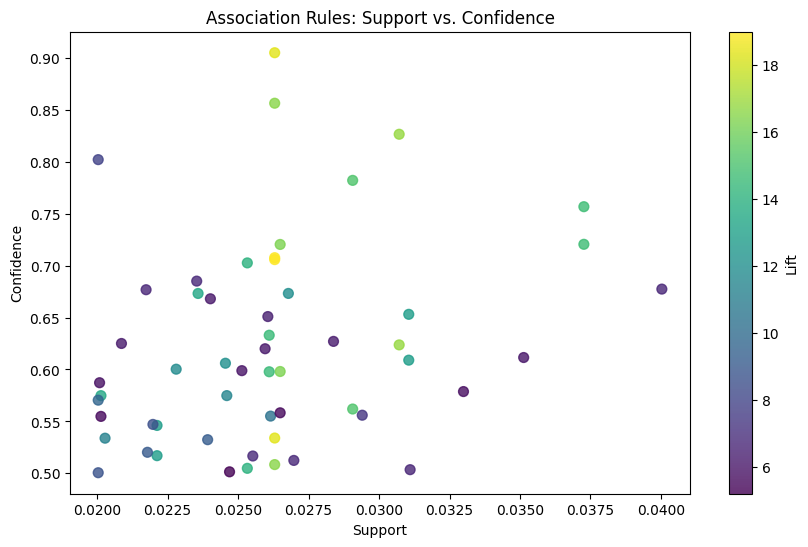

In [ ]:
import matplotlib.pyplot as plt

# Create the scatter plot
plt.figure(figsize=(10, 6))
scatter = plt.scatter(filtered_rules['support'], filtered_rules['confidence'],
                      c=filtered_rules['lift'], cmap='viridis', alpha=0.8, s=50)

# Add a colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Lift')

# Add labels and title
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.title('Association Rules: Support vs. Confidence')

# Show the plot
plt.show()

A summary of the most actionable and interesting rules discovered from the filtered list.



In [ ]:
print("Top 5 most actionable rules based on lift:\n")
for index, row in filtered_rules.head(5).iterrows():
    antecedents = ', '.join(list(row['antecedents']))
    consequents = ', '.join(list(row['consequents']))
    print(f"Rule: {antecedents} -> {consequents}")
    print(f"Support: {row['support']:.4f}")
    print(f"Confidence: {row['confidence']:.4f}")
    print(f"Lift: {row['lift']:.4f}\n")

Top 5 most actionable rules based on lift:

Rule: PINK REGENCY TEACUP AND SAUCER -> ROSES REGENCY TEACUP AND SAUCER, GREEN REGENCY TEACUP AND SAUCER
Support: 0.0263
Confidence: 0.7076
Lift: 18.9874

Rule: ROSES REGENCY TEACUP AND SAUCER, GREEN REGENCY TEACUP AND SAUCER -> PINK REGENCY TEACUP AND SAUCER
Support: 0.0263
Confidence: 0.7057
Lift: 18.9874

Rule: PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY TEACUP AND SAUCER -> GREEN REGENCY TEACUP AND SAUCER
Support: 0.0263
Confidence: 0.9048
Lift: 18.3723

Rule: GREEN REGENCY TEACUP AND SAUCER -> PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY TEACUP AND SAUCER
Support: 0.0263
Confidence: 0.5340
Lift: 18.3723

Rule: PINK REGENCY TEACUP AND SAUCER -> GREEN REGENCY TEACUP AND SAUCER
Support: 0.0307
Confidence: 0.8264
Lift: 16.7790



## Summary:

### Q&A

**Question:** What are the most actionable and interesting rules discovered from the market basket analysis?
**Answer:** The most actionable and interesting rules center around the "REGENCY TEACUP AND SAUCER" product line. The analysis revealed extremely strong associations between the Pink, Green, and Roses variations of these teacups. For example, buying the Pink teacup and saucer is highly associated with buying the Roses and Green versions, showing a very high lift of approximately 18.98 and a confidence level of roughly 0.90.


### Data Analysis Key Findings

*   **Frequent Itemsets:** Applying the Apriori algorithm with a minimum support of 0.02 revealed that the top-selling individual items include the "WHITE HANGING HEART T-LIGHT HOLDER" (with a support of ~0.11), followed by the "JUMBO BAG RED RETROSPOT" and "REGENCY CAKESTAND 3 TIER".
*   **Association Rules Generation:** Initially, 160 association rules were generated based on a minimum lift threshold of 1.0.
*   **Significant Rules Filtered:** By applying strict filters (confidence >= 0.5 and lift >= 2.0), the rules were narrowed down to 55 highly significant and actionable patterns.
*   **Visualizations:** A scatter plot of Support vs. Confidence (colored by Lift) successfully highlighted the strongest product relationships, making it easy to spot rules with massive cross-selling potential (lift near 18.9).

### Insights or Next Steps

*   **Create Product Bundles:** Capitalize on the strong relationships within the "REGENCY TEACUP AND SAUCER" collection by bundling the Pink, Green, and Roses variations together at a slight discount to drive higher average order values.
*   **Optimize Store Layout / Recommendations:** Ensure that top-selling baseline items like the "WHITE HANGING HEART T-LIGHT HOLDER" are prominently featured, and dynamically recommend the related "REGENCY" teacups on the product pages of any single teacup variation.

### Apriori Algorithm

The Apriori algorithm uses a "bottom-up" approach, where frequent subsets are extended one item at a time (candidate generation), and groups of candidates are tested against the data.

**Algorithm Steps:**
1.  **L1 (Frequent 1-itemsets)**: Find all individual items that satisfy the minimum support threshold.
2.  **Generate Candidates (Ck)**: Use the frequent itemsets of size $k-1$ to generate potential itemsets of size $k$ (Join Step).
3.  **Pruning**: Remove candidates if any of their subsets are not frequent (based on the Apriori property: all subsets of a frequent itemset must also be frequent).
4.  **Count Support**: Scan the database to calculate the actual support for each candidate in $C_k$.
5.  **Filter (Lk)**: Keep only those candidates that meet the minimum support.
6.  **Repeat**: Increment $k$ and repeat until no more frequent itemsets can be found.

In [10]:
from itertools import combinations

def get_support(df, itemset):
    # Calculate support for a given itemset in a boolean DataFrame
    return df[list(itemset)].all(axis=1).mean()

def simple_apriori(df, min_support):
    items = list(df.columns)
    frequent_itemsets = {}

    # 1. Find frequent 1-itemsets
    current_frequent = []
    for item in items:
        support = get_support(df, [item])
        if support >= min_support:
            current_frequent.append(frozenset([item]))
            frequent_itemsets[frozenset([item])] = support

    k = 2
    while current_frequent:
        # 2. Generate Candidates (Ck)
        candidates = set()
        for i in range(len(current_frequent)):
            for j in range(i + 1, len(current_frequent)):
                union = current_frequent[i] | current_frequent[j]
                if len(union) == k:
                    candidates.add(union)

        # 3. Filter Candidates by Support
        current_frequent = []
        for candidate in candidates:
            support = get_support(df, candidate)
            if support >= min_support:
                current_frequent.append(candidate)
                frequent_itemsets[candidate] = support
        k += 1

    return frequent_itemsets

# Test on a small subset of our data
print("Running custom Apriori implementation on subset...")
# Taking a subset of columns and rows for speed in this demonstration
test_cols = [col for col in basket_sets_bool.columns if 'REGENCY TEACUP' in col]
results = simple_apriori(basket_sets_bool[test_cols].head(1000), min_support=0.02)

for itemset, support in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"Support: {support:.3f} | Itemset: {list(itemset)}")

Running custom Apriori implementation on subset...
Support: 0.042 | Itemset: ['GREEN REGENCY TEACUP AND SAUCER']
Support: 0.040 | Itemset: ['ROSES REGENCY TEACUP AND SAUCER']
Support: 0.031 | Itemset: ['ROSES REGENCY TEACUP AND SAUCER', 'GREEN REGENCY TEACUP AND SAUCER']


### Association Rule Generation

Once frequent itemsets are found, rules are generated by splitting each itemset into two non-empty subsets: **Antecedent (A)** and **Consequent (C)**.

**Algorithm Steps:**
1.  **Iterate**: For each frequent itemset $L$ with at least 2 items.
2.  **Subset Generation**: Generate all non-empty proper subsets $A$ of $L$.
3.  **Form Rules**: For each subset $A$, create a rule $A \rightarrow C$, where $C = L - A$.
4.  **Calculate Metrics**:
    *   $Confidence(A \rightarrow C) = Support(L) / Support(A)$
    *   $Lift(A \rightarrow C) = Confidence(A \rightarrow C) / Support(C)$
5.  **Filter**: Keep only rules that meet the minimum confidence and lift thresholds.

In [12]:
def generate_rules_from_scratch(frequent_itemsets, min_confidence=0.5):
    rules = []
    # frequent_itemsets is a dict: {frozenset: support}

    for itemset, support_L in frequent_itemsets.items():
        if len(itemset) < 2:
            continue

        # Generate all possible antecedents (proper subsets)
        items = list(itemset)
        for r in range(1, len(items)):
            for antecedent_tuple in combinations(items, r):
                antecedent = frozenset(antecedent_tuple)
                consequent = itemset - antecedent

                support_A = frequent_itemsets.get(antecedent)
                support_C = frequent_itemsets.get(consequent)

                if support_A:
                    confidence = support_L / support_A
                    if confidence >= min_confidence:
                        lift = confidence / support_C
                        rules.append({
                            'antecedent': list(antecedent),
                            'consequent': list(consequent),
                            'support': support_L,
                            'confidence': confidence,
                            'lift': lift
                        })
    return rules

# Run rule generation on the Regency Teacup results from earlier
print("Generating rules from teacup itemsets...")
custom_rules = generate_rules_from_scratch(results, min_confidence=0.5)

# Display top rules
for r in sorted(custom_rules, key=lambda x: x['lift'], reverse=True):
    print(f"Rule: {r['antecedent']} -> {r['consequent']}")
    print(f" - Confidence: {r['confidence']:.3f}, Lift: {r['lift']:.3f}\n")

Generating rules from teacup itemsets...
Rule: ['ROSES REGENCY TEACUP AND SAUCER'] -> ['GREEN REGENCY TEACUP AND SAUCER']
 - Confidence: 0.775, Lift: 18.452

Rule: ['GREEN REGENCY TEACUP AND SAUCER'] -> ['ROSES REGENCY TEACUP AND SAUCER']
 - Confidence: 0.738, Lift: 18.452



## Exercises

### Exercise 1: Support Calculation

Imagine a small dataset of 10 transactions:

1.  `{Milk, Bread}`
2.  `{Milk, Diapers}`
3.  `{Bread, Diapers}`
4.  `{Milk, Bread, Diapers}`
5.  `{Milk, Bread}`
6.  `{Diapers}`
7.  `{Bread, Diapers}`
8.  `{Milk, Bread, Diapers}`
9.  `{Milk}`
10. `{Bread}`

**Question**: What is the support for the itemset `{Milk, Bread}`?

### Answer 1

To calculate the support for `{Milk, Bread}`:

*   **Count transactions containing `{Milk, Bread}`**: Transactions 1, 4, 5, 8 contain both Milk and Bread.
    *   Count = 4
*   **Total transactions**: 10

*   **Support**: `4 / 10 = 0.40` (or 40%)

The support for `{Milk, Bread}` is **0.40**.

### Exercise 2: Confidence Calculation

Using the same dataset from Exercise 1, consider the rule `{Diapers} -> {Milk}`.

**Question**: What is the confidence for this rule?

### Answer 2

To calculate the confidence for `{Diapers} -> {Milk}`:

*   **Count transactions containing `{Diapers}` (antecedent)**: Transactions 2, 3, 4, 6, 7, 8 contain Diapers.
    *   Count = 6
*   **Count transactions containing `{Diapers, Milk}` (antecedent and consequent together)**: Transactions 2, 4, 8 contain both Diapers and Milk.
    *   Count = 3

*   **Confidence**: `(Transactions with {Diapers, Milk}) / (Transactions with {Diapers})`
    *   `3 / 6 = 0.50` (or 50%)

The confidence for `{Diapers} -> {Milk}` is **0.50**.

### Exercise 3: Lift Calculation

Given the following:

*   `Support({A}) = 0.20`
*   `Support({B}) = 0.25`
*   `Support({A, B}) = 0.15`

**Question**: Calculate the Lift for the rule `{A} -> {B}`.

### Answer 3

To calculate the Lift for `{A} -> {B}`:

First, calculate the confidence:
*   `Confidence({A} -> {B}) = Support({A, B}) / Support({A})`
*   `Confidence({A} -> {B}) = 0.15 / 0.20 = 0.75`

Now, calculate the Lift:
*   `Lift({A} -> {B}) = Confidence({A} -> {B}) / Support({B})`
*   `Lift({A} -> {B}) = 0.75 / 0.25 = 3.0`

Alternatively, using the other formula:
*   `Lift({A} -> {B}) = Support({A, B}) / (Support({A}) * Support({B}))`
*   `Lift({A} -> {B}) = 0.15 / (0.20 * 0.25)`
*   `Lift({A} -> {B}) = 0.15 / 0.05 = 3.0`

The Lift for `{A} -> {B}` is **3.0**.

### Exercise 4: Interpreting Lift

A marketing team finds a rule `{ProductX} -> {ProductY}` with a confidence of 0.60 and a lift of 0.80.

**Question**: How should the marketing team interpret this lift value? What does it suggest about the relationship between ProductX and ProductY?

### Answer 4

*   **Lift < 1** indicates a *negative correlation*. This means that the presence of the antecedent (ProductX) *decreases* the likelihood of the consequent (ProductY) being purchased, or that they occur together *less frequently* than would be expected if they were statistically independent.

*   **Interpretation**: The marketing team should interpret this as `ProductX` and `ProductY` being **substitutes** or otherwise negatively associated. Buying `ProductX` makes a customer *less likely* to buy `ProductY` compared to the general probability of buying `ProductY`. It would not be effective to cross-promote `ProductY` to customers buying `ProductX`; in fact, it might suggest offering one instead of the other.

### Exercise 5: Combined Interpretation

Consider two rules discovered from a large online retail dataset:

1.  `{Coffee} -> {Sugar}`: Support = 0.05, Confidence = 0.80, Lift = 1.2
2.  `{Espresso Machine} -> {Specialty Coffee Beans}`: Support = 0.008, Confidence = 0.65, Lift = 4.5

**Question**: Which rule is more "interesting" or actionable from a business perspective, and why?

### Answer 5

*   **Rule 1: `{Coffee} -> {Sugar}`**
    *   **Support = 0.05 (5%)**: This is a moderately frequent co-occurrence.
    *   **Confidence = 0.80 (80%)**: When someone buys coffee, they buy sugar 80% of the time, which is quite reliable.
    *   **Lift = 1.2**: This indicates a positive correlation, but it's not extremely strong. Coffee and sugar are bought together 1.2 times more often than expected by chance.

*   **Rule 2: `{Espresso Machine} -> {Specialty Coffee Beans}`**
    *   **Support = 0.008 (0.8%)**: This co-occurrence is less frequent overall.
    *   **Confidence = 0.65 (65%)**: When someone buys an espresso machine, they buy specialty coffee beans 65% of the time, which is still quite reliable.
    *   **Lift = 4.5**: This is a *very strong positive correlation*. It means customers buying an espresso machine are 4.5 times more likely to buy specialty coffee beans than expected by chance.

**Conclusion**: Rule 2, **`{Espresso Machine} -> {Specialty Coffee Beans}`**, is more "interesting" and actionable from a business perspective, despite having lower support.

**Why?**

*   **Higher Lift**: The much higher lift (4.5 vs 1.2) for Rule 2 indicates a significantly stronger and less obvious association. It suggests a powerful, non-random relationship that can be leveraged.
*   **Actionability**: While Rule 1 is reliable, the association between coffee and sugar is somewhat expected (common complimentary items). Rule 2, however, reveals a deeper insight into customer behavior for higher-value items. It suggests a clear cross-selling opportunity: customers investing in an espresso machine are highly inclined to also purchase specialty beans. This could inform product bundling, targeted recommendations, or even store layout for high-margin items.

High lift often points to truly novel and valuable insights that can drive strategic business decisions, even if the overall frequency (support) of the event is lower.